In [2]:
import numpy as np


def read_latency_data(file, ignore):
    data = {"end_to_end": [], "service": []}
    with open(file, "r") as file:
        for line in file.readlines():
            span, latency = line.strip().split(",")
            assert span in data.keys()
            data[span].append(int(latency))
    for span in data.keys():
        n_ignore = int(len(data[span]) * ignore)
        data[span] = data[span][n_ignore:]
    return data 


def get_pctl(data, pctl):
    data = np.sort(data)
    tail = np.percentile(data, pctl).astype(int)
    return tail

In [3]:
rps_values = list(range(100, 2001, 100))
e2e_data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
}
svc_data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
}

pctl = 99
for rps in rps_values:
    e2e_data["rps"].append(rps)
    svc_data["rps"].append(rps)

    file = f"r{rps}-fcfs.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["fcfs"].append(get_pctl(data["end_to_end"], pctl))
    svc_data["fcfs"].append(get_pctl(data["service"], pctl))

    file = f"r{rps}-masa.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["masa"].append(get_pctl(data["end_to_end"], pctl))
    svc_data["masa"].append(get_pctl(data["service"], pctl))

print(e2e_data)
print()
print(svc_data)

{'rps': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000], 'fcfs': [39960, 42006, 45066, 47482, 50780, 55084, 58696, 64119, 69704, 75891, 85395, 94994, 108090, 126887, 152543, 192306, 251732, 370412, 762896, 892544], 'masa': [39949, 41771, 44173, 46431, 48618, 51773, 54692, 58404, 62129, 67017, 73448, 81434, 91245, 104143, 125904, 155394, 210747, 296488, 598474, 717193]}

{'rps': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000], 'fcfs': [9135, 9384, 9432, 9744, 10136, 11048, 11460, 12654, 14153, 15715, 18109, 20640, 24044, 28074, 35134, 45294, 56931, 90090, 183427, 232366], 'masa': [9139, 9396, 9456, 9883, 10286, 11436, 12312, 13825, 15825, 18006, 21038, 24884, 29384, 34506, 43521, 52555, 70876, 102342, 188312, 299188]}


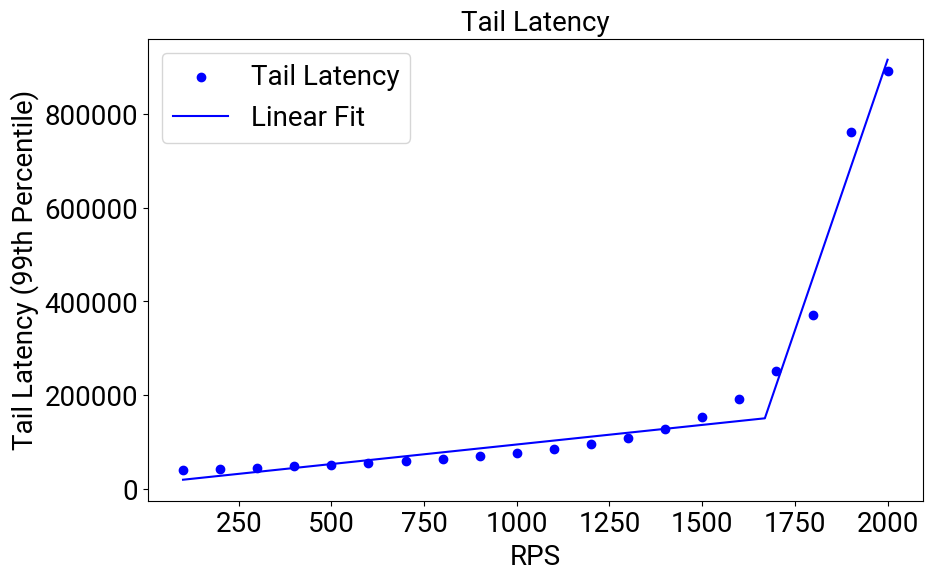

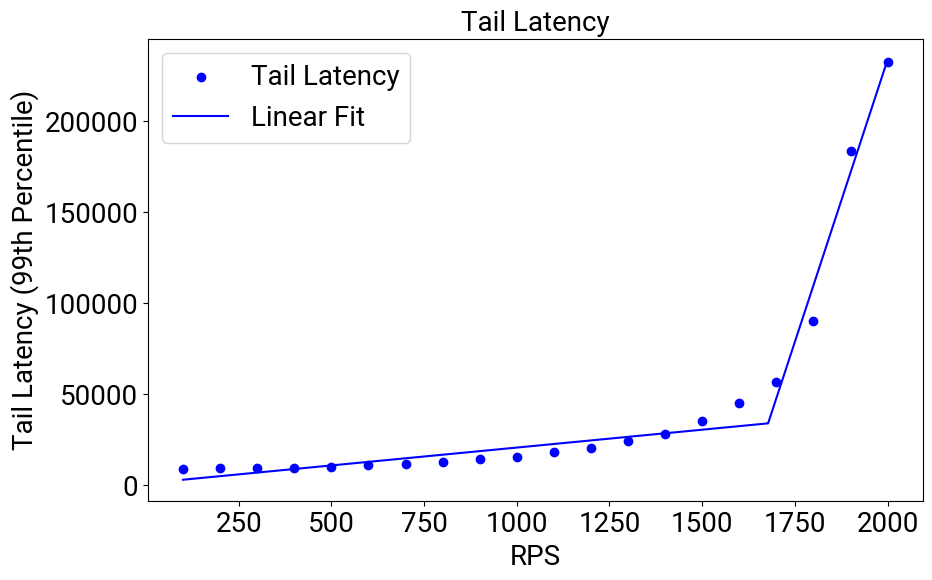

30000 230 3000 98 2.36
40000 350 4000 149 2.355
50000 470 5000 200 2.353
60000 589 6000 251 2.351
70000 709 7000 302 2.35
80000 828 8000 352 2.35
90000 948 9000 403 2.349
100000 1068 10000 454 2.349
110000 1187 11000 505 2.349
120000 1307 12000 556 2.348
130000 1426 13000 607 2.348
140000 1546 14000 658 2.348
150000 1665 15000 709 2.348
160000 1673 16000 760 2.201
170000 1677 17000 811 2.068
180000 1682 18000 862 1.95
190000 1686 19000 913 1.846
200000 1690 20000 964 1.753
210000 1695 21000 1015 1.669
220000 1699 22000 1066 1.594
230000 1703 23000 1117 1.525
240000 1708 24000 1168 1.462
250000 1712 25000 1219 1.404
260000 1716 26000 1270 1.351
270000 1721 27000 1321 1.303
280000 1725 28000 1372 1.257
290000 1729 29000 1423 1.215
300000 1734 30000 1474 1.176


/tmp/ipykernel_1136103/839110866.py:34: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  return fsolve(lambda x: p(x) - target, 1000)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pwlf
from scipy.optimize import fsolve


def plot(data):
    n_points = len(data["rps"])
    x = np.array(data["rps"][:n_points])
    y1 = np.array(data["fcfs"][:n_points])
    # y2 = np.array(data["masa"][:n_points])

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y1, color="blue", label="Tail Latency")
    # plt.scatter(x, y2, color="green", label="Data y2")

    fit = pwlf.PiecewiseLinFit(x, y1)
    fit.fit(2)
    x_hat = np.linspace(min(x), max(x), num=10000)
    y_hat = fit.predict(x_hat)
    plt.plot(x_hat, y_hat, color="blue", label="Linear Fit")

    plt.title("Tail Latency")
    plt.xlabel("RPS")
    plt.ylabel("Tail Latency (99th Percentile)")
    plt.legend()
    plt.show()

    return fit


def solve(p, target):
    return fsolve(lambda x: p(x) - target, 1000)


e2e_fit = plot(e2e_data)
svc_fit = plot(svc_data)

slos = list(range(30000, 300001, 10000))
data = {
    "slo1": [],
    "rps1": [],
    "slo2": [],
    "rps2": [],
}
for slo in slos:
    slo1 = slo
    slo2 = slo / 10
    rps1 = solve(e2e_fit.predict, slo1)[0]
    assert abs(e2e_fit.predict(rps1) - slo1) < 1e-6
    rps2 = solve(svc_fit.predict, slo2)[0]
    assert abs(svc_fit.predict(rps2) - slo2) < 1e-6
    data["slo1"].append(slo1)
    data["rps1"].append(rps1)
    data["slo2"].append(slo2)
    data["rps2"].append(rps2)
    print(
        round(slo1),
        round(rps1),
        round(slo2),
        round(rps2),
        round(rps1 / rps2, 3),
    )

In [5]:
print(data)
raw = data

{'slo1': [30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000, 110000, 120000, 130000, 140000, 150000, 160000, 170000, 180000, 190000, 200000, 210000, 220000, 230000, 240000, 250000, 260000, 270000, 280000, 290000, 300000], 'rps1': [230.35059516527917, 349.94473848897644, 469.53888181267365, 589.1330251363707, 708.727168460068, 828.3213117837653, 947.9154551074623, 1067.5095984311597, 1187.1037417548569, 1306.6978850785542, 1426.2920284022512, 1545.8861717259483, 1665.4803150496455, 1673.148967892419, 1677.4687715341088, 1681.7885751757988, 1686.1083788174885, 1690.4281824591785, 1694.7479861008683, 1699.0677897425583, 1703.387593384248, 1707.707397025938, 1712.0272006676278, 1716.3470043093178, 1720.6668079510075, 1724.9866115926975, 1729.3064152343873, 1733.6262188760772], 'slo2': [3000.0, 4000.0, 5000.0, 6000.0, 7000.0, 8000.0, 9000.0, 10000.0, 11000.0, 12000.0, 13000.0, 14000.0, 15000.0, 16000.0, 17000.0, 18000.0, 19000.0, 20000.0, 21000.0, 22000.0, 23000.0, 24000.0, 25000.0, 2

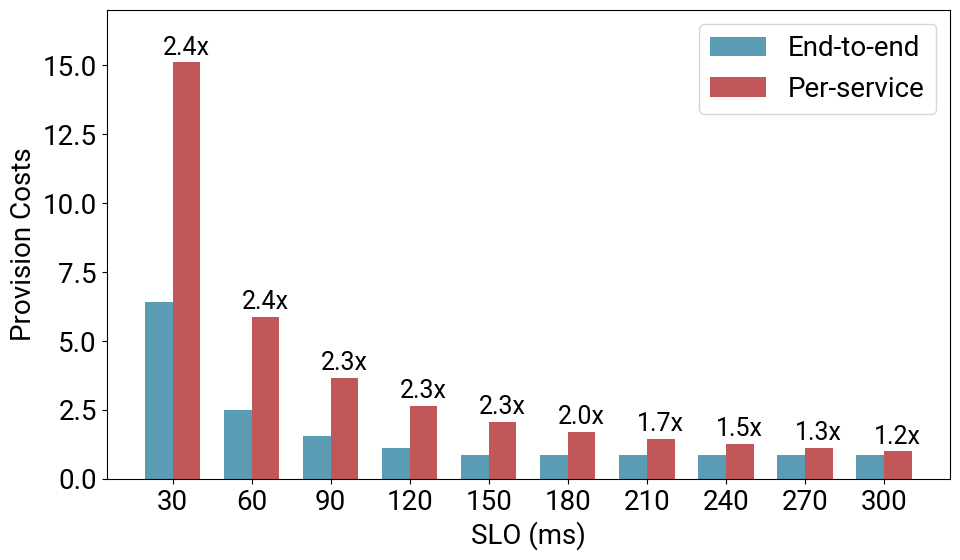

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "Roboto"

plt.rcParams.update(
    {
        "font.size": 20,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 20,
    }
)

data = {"x": [], "y1": [], "y2": [], "rel": []}

for i in range(0, len(raw["rps1"]), 3):
    data["x"].append(raw["slo1"][i])
    data["y1"].append(raw["rps1"][i])
    data["y2"].append(raw["rps2"][i])

min_y2 = max(data["y2"])
data["z1"] = [min_y2 / y1 for y1 in data["y1"]]
data["z2"] = [min_y2 / y2 for y2 in data["y2"]]

data["x"] = [round(x / 1e3) for x in data["x"]]

for i in range(len(data["x"])):
    data["rel"].append(data["y1"][i] / data["y2"][i])

x = np.arange(len(data["x"]))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(
    x - width / 2,
    data["z1"],
    width,
    label="End-to-end",
    color="#599CB4",
)
rects2 = ax.bar(
    x + width / 2,
    data["z2"],
    width,
    label="Per-service",
    color="#C25759",
)

for i, rel in enumerate(data["rel"]):
    ax.text(
        x[i] + width / 2,
        data["z2"][i] + 0.1,
        f"{rel:.1f}x",
        ha="center",
        va="bottom",
        color="black",
        fontsize=18,
    )

# ax.set_title("Deadline Difference = 8 ms")
ax.set_xlabel("SLO (ms)")
ax.set_ylabel("Provision Costs")
ax.set_ylim(0, 17)
ax.set_xticks(x)
ax.set_xticklabels(data["x"])
ax.legend()

fig.tight_layout()
plt.savefig("e2e_vs_service.pdf")
plt.show()

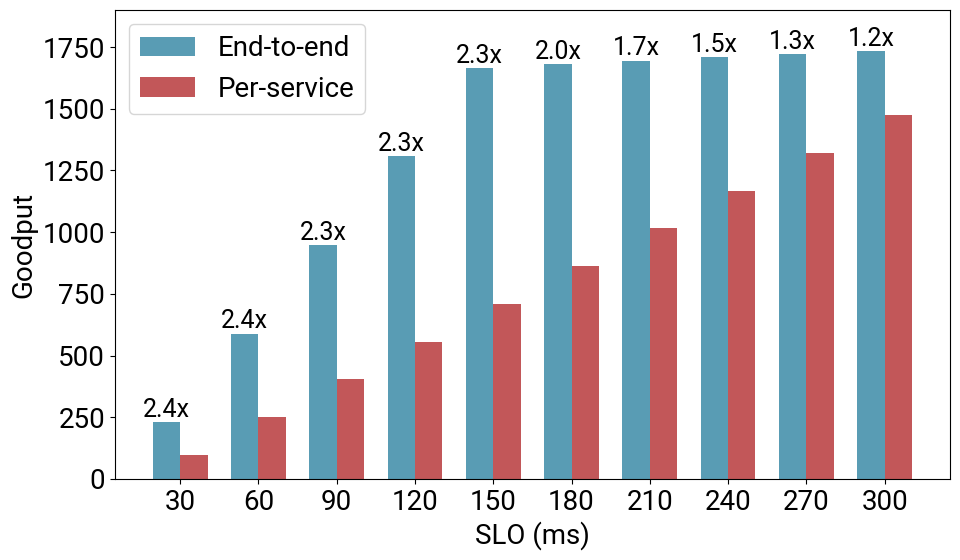

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "Roboto"

plt.rcParams.update(
    {
        "font.size": 20,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 20,
    }
)

data = {"x": [], "y1": [], "y2": [], "rel": []}

for i in range(0, len(raw["rps1"]), 3):
    data["x"].append(raw["slo1"][i])
    data["y1"].append(raw["rps1"][i])
    data["y2"].append(raw["rps2"][i])

data["x"] = [round(x / 1e3) for x in data["x"]]

for i in range(len(data["x"])):
    data["rel"].append(data["y1"][i] / data["y2"][i])

x = np.arange(len(data["x"]))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(
    x - width / 2,
    data["y1"],
    width,
    label="End-to-end",
    color="#599CB4",
)
rects2 = ax.bar(
    x + width / 2,
    data["y2"],
    width,
    label="Per-service",
    color="#C25759",
)

for i, rel in enumerate(data["rel"]):
    ax.text(
        x[i] - width / 2,
        data["y1"][i] + 1,
        f"{rel:.1f}x",
        ha="center",
        va="bottom",
        color="black",
        fontsize=18,
    )

# ax.set_title("Deadline Difference = 8 ms")
ax.set_xlabel("SLO (ms)")
ax.set_ylabel("Goodput")
ax.set_ylim(0, 1900)
ax.set_xticks(x)
ax.set_xticklabels(data["x"])
ax.legend()

fig.tight_layout()
plt.savefig("e2e_vs_service.pdf")
plt.show()